In [1]:
import os
import sys
import glob
import awkward as ak
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
from torch.utils.data import ConcatDataset
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool
from torch_geometric.nn import GCNConv as gcn
from torch_geometric.nn import EdgeConv 
from torch_geometric.nn import DynamicEdgeConv 
from sklearn.metrics import roc_curve, auc

In [2]:
sys.path.append('modules') #direct to our module package
import architectures as arch

In [3]:
SEED = 2026
np.random.seed(SEED)    # Setting the seed for reproducibility
torch.manual_seed(SEED)

validation_directory = "/standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all"
validation_paths = glob.glob(os.path.join(validation_directory, "v*"))
print(validation_paths)

['/standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_signal_signal_50_graphs.pt', '/standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_signal_signal_5_graphs.pt', '/standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_signal_signal_100_graphs.pt', '/standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_signal_signal_10_graphs.pt', '/standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_enriched_merged.pt']


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
num_gpus = torch.cuda.device_count()

print("Beginning to load validation files")
val_file_list = []
for path in validation_paths:
    val_file_list.append((torch.load(path, weights_only = False)))
    print(f"Loaded: {path}")

Beginning to load validation files
Loaded: /standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_signal_signal_50_graphs.pt
Loaded: /standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_signal_signal_5_graphs.pt
Loaded: /standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_signal_signal_100_graphs.pt
Loaded: /standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_signal_signal_10_graphs.pt
Loaded: /standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_enriched_merged.pt


In [6]:
trained_model_state_dict = torch.load('/standard/ldmxuva/gnn_files/run_output/dynamic_run_extended_best_model.pt', weights_only = True)
model_preloaded = arch.GNN_v3_dynamic(in_channels = 4, 
                                     hc1 = 10, hc2 = 20, hc3 = 40, hc4 = 50, 
                                     fc1 = 25, fc2 = 12, fc3 = 6, 
                                     k1 = 33, k2 = 25, k3 = 17, k4 = 9,
                                     out_channels = 2)
model_preloaded.load_state_dict(trained_model_state_dict)
model_preloaded = model_preloaded.to(device)
model_preloaded.eval()

GNN_v3_dynamic(
  (ECal_branch): DynamicEdgeConvBlock(
    (mlp1): Sequential(
      (0): Linear(in_features=8, out_features=10, bias=True)
      (1): ReLU()
      (2): Linear(in_features=10, out_features=10, bias=True)
    )
    (mlp2): Sequential(
      (0): Linear(in_features=20, out_features=20, bias=True)
      (1): ReLU()
      (2): Linear(in_features=20, out_features=20, bias=True)
    )
    (mlp3): Sequential(
      (0): Linear(in_features=40, out_features=40, bias=True)
      (1): ReLU()
      (2): Linear(in_features=40, out_features=40, bias=True)
    )
    (mlp4): Sequential(
      (0): Linear(in_features=80, out_features=50, bias=True)
      (1): ReLU()
      (2): Linear(in_features=50, out_features=50, bias=True)
    )
    (edgeconv1): DynamicEdgeConv(nn=Sequential(
      (0): Linear(in_features=8, out_features=10, bias=True)
      (1): ReLU()
      (2): Linear(in_features=10, out_features=10, bias=True)
    ), k=33)
    (edgeconv2): DynamicEdgeConv(nn=Sequential(
      (0

In [7]:
val_file_list[4] = [item for sublist in val_file_list[4] for item in sublist]

# Verify
print(type(val_file_list[4][0]))  # Should now be torch_geometric.data.data.Data

m050_bkgd_roc_sample = val_file_list[4]+val_file_list[0]
m010_bkgd_roc_sample = val_file_list[4]+val_file_list[3]
m100_bkgd_roc_sample = val_file_list[4]+val_file_list[2]
m005_bkgd_roc_sample = val_file_list[4]+val_file_list[1]

m010_roc_sample_loader = DataLoader(m010_bkgd_roc_sample, batch_size = 500, drop_last = True, shuffle=True, num_workers=1)
m005_roc_sample_loader = DataLoader(m005_bkgd_roc_sample, batch_size = 500, drop_last = True, shuffle=True, num_workers=1)
m100_roc_sample_loader = DataLoader(m100_bkgd_roc_sample, batch_size = 500, drop_last = True, shuffle=True, num_workers=1)
m050_roc_sample_loader = DataLoader(m050_bkgd_roc_sample, batch_size = 500, drop_last = True, shuffle=True, num_workers=1)

<class 'torch_geometric.data.data.Data'>


In [8]:
all_labels005 = []
for batch in m005_roc_sample_loader:
    all_labels005.append(batch.y)
all_labels005 = torch.cat(all_labels005)
print(f"Split -> bkgd {(torch.bincount(all_labels005))[0]}, m005 {(torch.bincount(all_labels005))[1]}")

all_labels010 = []
for batch in m010_roc_sample_loader:
    all_labels010.append(batch.y)
all_labels010 = torch.cat(all_labels010)
torch.bincount(all_labels010)
print(f"Split -> bkgd {(torch.bincount(all_labels010))[0]}, m010 {(torch.bincount(all_labels010))[1]}")

all_labels050 = []
for batch in m050_roc_sample_loader:
    all_labels050.append(batch.y)
all_labels050 = torch.cat(all_labels050)
torch.bincount(all_labels050)
print(f"Split -> bkgd {(torch.bincount(all_labels050))[0]}, m050 {(torch.bincount(all_labels050))[1]}")

all_labels100 = []
for batch in m100_roc_sample_loader:
    all_labels100.append(batch.y)
all_labels100 = torch.cat(all_labels100)
torch.bincount(all_labels100)
print(f"Split -> bkgd {(torch.bincount(all_labels100))[0]}, m100 {(torch.bincount(all_labels100))[1]}")

Split -> bkgd 37334, m005 26666
Split -> bkgd 37371, m010 27629
Split -> bkgd 37431, m050 27569
Split -> bkgd 37551, m100 27949


In [9]:
y_scores_m010 = []
y_true_m010 = []

y_scores_m005 = []
y_true_m005 = []

y_scores_m100 = []
y_true_m100 = []

y_scores_m050 = []
y_true_m050 = []

print(f"Using device: {device} ({num_gpus} GPUs available)")

with torch.no_grad():
    for data in m010_roc_sample_loader:
        # Move batch to GPU
        data = data.to(device)

        # Forward pass on GPU
        out = model_preloaded(data)

        # Assuming binary classification and out shape [N, 2]
        probs = torch.softmax(out, dim=1)[:, 1]

        # Only CPU when appending
        y_scores_m010.append(probs.cpu())
        y_true_m010.append(data.y.cpu())
    print("done!")

    for data in m005_roc_sample_loader:
        # Move batch to GPU
        data = data.to(device)

        # Forward pass on GPU
        out = model_preloaded(data)

        # Assuming binary classification and out shape [N, 2]
        probs = torch.softmax(out, dim=1)[:, 1]

        # Only CPU when appending
        y_scores_m005.append(probs.cpu())
        y_true_m005.append(data.y.cpu())
    print("done!")

    for data in m100_roc_sample_loader:
        # Move batch to GPU
        data = data.to(device)

        # Forward pass on GPU
        out = model_preloaded(data)

        # Assuming binary classification and out shape [N, 2]
        probs = torch.softmax(out, dim=1)[:, 1]

        # Only CPU when appending
        y_scores_m100.append(probs.cpu())
        y_true_m100.append(data.y.cpu())
    print("done!")

    for data in m050_roc_sample_loader:
        # Move batch to GPU
        data = data.to(device)

        # Forward pass on GPU
        out = model_preloaded(data)

        # Assuming binary classification and out shape [N, 2]
        probs = torch.softmax(out, dim=1)[:, 1]

        # Only CPU when appending
        y_scores_m050.append(probs.cpu())
        y_true_m050.append(data.y.cpu())
    print("done!")

y_true_m010 = torch.cat(y_true_m010).numpy()
y_scores_m010 = torch.cat(y_scores_m010).numpy()

y_true_m005 = torch.cat(y_true_m005).numpy()
y_scores_m005 = torch.cat(y_scores_m005).numpy()

y_true_m100 = torch.cat(y_true_m100).numpy()
y_scores_m100 = torch.cat(y_scores_m100).numpy()

y_true_m050 = torch.cat(y_true_m050).numpy()
y_scores_m050 = torch.cat(y_scores_m050).numpy()

fpr005, tpr005, thresholds005 = roc_curve(y_true_m005, y_scores_m005)
roc_auc_005 = auc(fpr005, tpr005)

fpr050, tpr050, thresholds050 = roc_curve(y_true_m050, y_scores_m050)
roc_auc_050 = auc(fpr050, tpr050)

fpr010, tpr010, thresholds010 = roc_curve(y_true_m010, y_scores_m010)
roc_auc_010 = auc(fpr010, tpr010)

fpr100, tpr100, thresholds100 = roc_curve(y_true_m100, y_scores_m100)
roc_auc_100 = auc(fpr100, tpr100)

Using device: cuda (1 GPUs available)
done!
done!
done!
done!


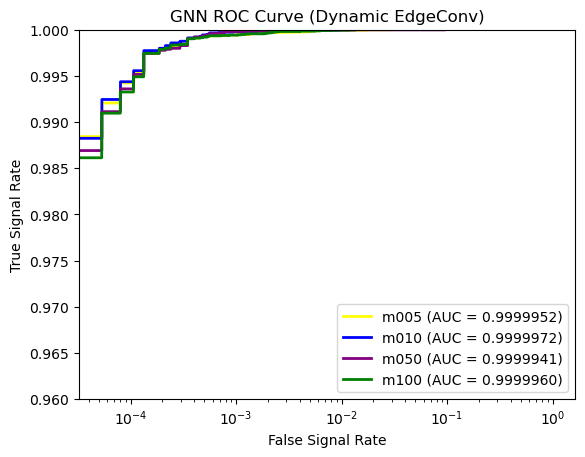

<Figure size 640x480 with 0 Axes>

In [10]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr005, tpr005, color='yellow', lw=2, label=f'm005 (AUC = {roc_auc_005:.7f})')
plt.plot(fpr010, tpr010, color='blue', lw=2, label=f'm010 (AUC = {roc_auc_010:.7f})')
plt.plot(fpr050, tpr050, color='purple', lw=2, label=f'm050 (AUC = {roc_auc_050:.7f})')
plt.plot(fpr100, tpr100, color='green', lw=2, label=f'm100 (AUC = {roc_auc_100:.7f})')
#plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
#plt.xlim([-0.00001, 0.001])
#plt.xlim([0,0.1])
plt.xscale('log')
plt.ylim([0.96, 1])
plt.xlabel('False Signal Rate')
plt.ylabel('True Signal Rate')
plt.title('GNN ROC Curve (Dynamic EdgeConv)')
plt.legend(loc="lower right")
plt.show()
plt.savefig("GNN_roc_curve.png")

In [11]:
m010_gnnout_sample_loader = DataLoader(val_file_list[3], batch_size = 500, drop_last = True, shuffle=True, num_workers=1)
m005_gnnout_sample_loader = DataLoader(val_file_list[1], batch_size = 500, drop_last = True, shuffle=True, num_workers=1)
m100_gnnout_sample_loader = DataLoader(val_file_list[2], batch_size = 500, drop_last = True, shuffle=True, num_workers=1)
m050_gnnout_sample_loader = DataLoader(val_file_list[0], batch_size = 500, drop_last = True, shuffle=True, num_workers=1)
bkgd_gnnout_sample_loader = DataLoader(val_file_list[4], batch_size = 500, drop_last = True, shuffle=True, num_workers=1)

In [12]:
#Now lets do GNN scores plot:
m010_gnn_scores = []
m100_gnn_scores = []
m005_gnn_scores = []
m050_gnn_scores = []
bkgd_gnn_scores = []

with torch.no_grad():
    for data in m010_gnnout_sample_loader:
        # Move batch to GPU
        data = data.to(device)

        # Forward pass on GPU
        out = model_preloaded(data)

        # Assuming binary classification and out shape [N, 2]
        probs = torch.softmax(out, dim=1)[:, 1]

        # Only CPU when appending
        m010_gnn_scores.append(probs.cpu())
    print("done!")

    for data in m050_gnnout_sample_loader:
        # Move batch to GPU
        data = data.to(device)

        # Forward pass on GPU
        out = model_preloaded(data)

        # Assuming binary classification and out shape [N, 2]
        probs = torch.softmax(out, dim=1)[:, 1]

        # Only CPU when appending
        m050_gnn_scores.append(probs.cpu())
    print("done!")

    for data in m100_gnnout_sample_loader:
        # Move batch to GPU
        data = data.to(device)

        # Forward pass on GPU
        out = model_preloaded(data)

        # Assuming binary classification and out shape [N, 2]
        probs = torch.softmax(out, dim=1)[:, 1]

        # Only CPU when appending
        m100_gnn_scores.append(probs.cpu())
    print("done!")

    for data in m005_gnnout_sample_loader:
        # Move batch to GPU
        data = data.to(device)

        # Forward pass on GPU
        out = model_preloaded(data)

        # Assuming binary classification and out shape [N, 2]
        probs = torch.softmax(out, dim=1)[:, 1]

        # Only CPU when appending
        m005_gnn_scores.append(probs.cpu())
    print("done!")

    for data in bkgd_gnnout_sample_loader:
        # Move batch to GPU
        data = data.to(device)

        # Forward pass on GPU
        out = model_preloaded(data)

        # Assuming binary classification and out shape [N, 2]
        probs = torch.softmax(out, dim=1)[:, 1]

        # Only CPU when appending
        bkgd_gnn_scores.append(probs.cpu())
    print("done!")

done!
done!
done!
done!
done!


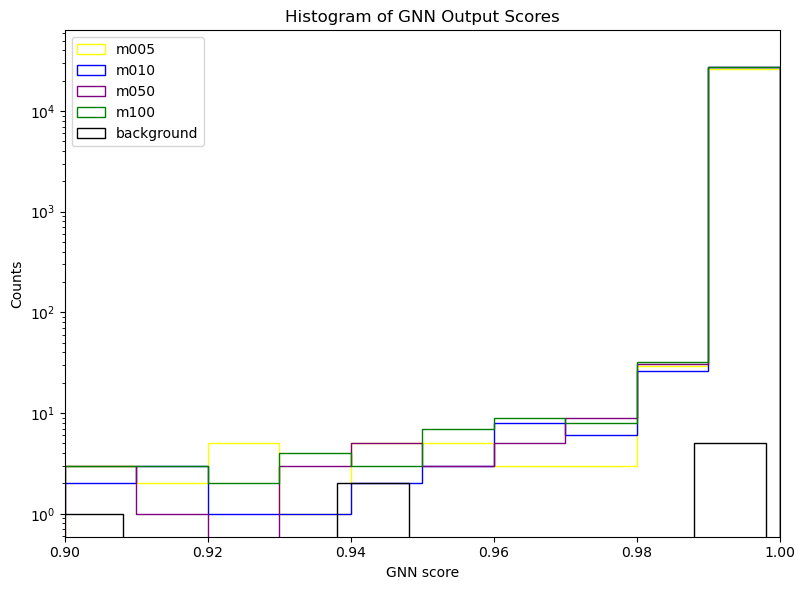

In [13]:
m010 = torch.cat(m010_gnn_scores).numpy()
m050 = torch.cat(m050_gnn_scores).numpy()
m100 = torch.cat(m100_gnn_scores).numpy()
m005 = torch.cat(m005_gnn_scores).numpy()
bkgd = torch.cat(bkgd_gnn_scores).numpy()

plt.figure(figsize=(8,6))

plt.hist(m005, bins=100, histtype="step", edgecolor = 'yellow', label="m005")
plt.hist(m010, bins=100, histtype="step", edgecolor = 'blue', label="m010")
plt.hist(m050, bins=100, histtype="step", edgecolor = 'purple', label="m050")
plt.hist(m100, bins=100, histtype="step", edgecolor = 'green', label="m100")
plt.hist(bkgd, bins=100, histtype="step", edgecolor = 'black', label="background")

plt.xlabel("GNN score")
plt.yscale('log')
plt.ylabel("Counts")
plt.title("Histogram of GNN Output Scores")
plt.legend()
plt.tight_layout()
plt.xlim((0.9,1))
plt.show()